# 04 — Model 2: Overflow Risk Classifier (XGBoost Classification)
Predicts `target_overflow_risk_next_day` — the probability a bin overflows before its next
scheduled reading. This is the "Overflow risk: 87%" style output from the brief, and the priority
weight fed into OR-Tools for route optimization.

See `ML_PIPELINE_PLAN.md` §6.2 for class-imbalance handling and threshold-selection rationale.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    confusion_matrix, classification_report,
)

from feature_engineering import (
    load_raw, build_features, merge_cluster_labels, cast_categorical_columns,
    chronological_split, get_model_frame, TARGET_CLASSIFICATION,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 50)


## 1. Load, engineer features, merge cluster labels

In [2]:
df = build_features(load_raw())
df = merge_cluster_labels(df)
# Cast categoricals ONCE on the full dataframe before splitting -- keeps
# category levels consistent across train/val/test/demo-sample subsets.
df = cast_categorical_columns(df, extra_categorical=["bin_cluster_id"])
train, val, test = chronological_split(df)

X_train, y_train, meta_train = get_model_frame(train, TARGET_CLASSIFICATION, extra_categorical=["bin_cluster_id"])
X_val,   y_val,   meta_val   = get_model_frame(val,   TARGET_CLASSIFICATION, extra_categorical=["bin_cluster_id"])
X_test,  y_test,  meta_test  = get_model_frame(test,  TARGET_CLASSIFICATION, extra_categorical=["bin_cluster_id"])
print(X_train.shape, X_val.shape, X_test.shape)

(84546, 62) (13860, 62) (14014, 62)


## 2. Class imbalance check

In [3]:
balance = y_train.value_counts(normalize=True).round(4)
print("Train class balance:\n", balance)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nscale_pos_weight = {scale_pos_weight:.2f}")

Train class balance:
 target_overflow_risk_next_day
0.0    0.8989
1.0    0.1011
Name: proportion, dtype: float64

scale_pos_weight = 8.90


## 3. Train XGBoost classifier

In [4]:
clf = xgb.XGBClassifier(
    objective="binary:logistic",
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    scale_pos_weight=scale_pos_weight,
    enable_categorical=True,
    tree_method="hist",
    random_state=42,
    early_stopping_rounds=30,
    eval_metric="aucpr",
)
clf.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print("Best iteration:", clf.best_iteration)

Best iteration: 416


## 4. Evaluate — PR-AUC first (imbalanced positive class), then ROC-AUC

In [5]:
proba_test = clf.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, proba_test)
pr_auc = average_precision_score(y_test, proba_test)
print(f"Test ROC-AUC: {roc_auc:.3f}")
print(f"Test PR-AUC:  {pr_auc:.3f}   (baseline PR-AUC for random = positive rate = {y_test.mean():.3f})")

Test ROC-AUC: 0.976
Test PR-AUC:  0.878   (baseline PR-AUC for random = positive rate = 0.098)


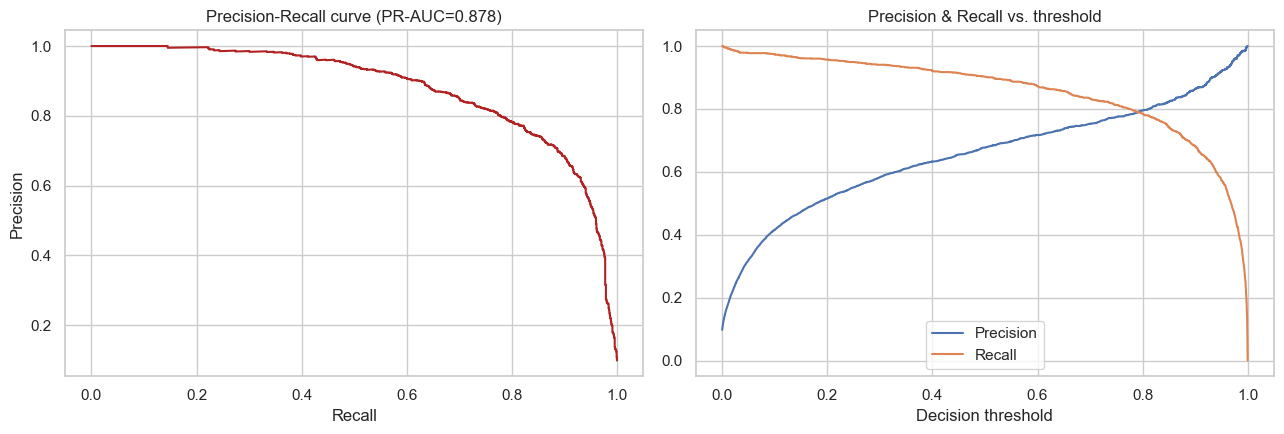

In [6]:
precisions, recalls, thresholds = precision_recall_curve(y_test, proba_test)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(recalls, precisions, color="firebrick")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title(f"Precision-Recall curve (PR-AUC={pr_auc:.3f})")

axes[1].plot(thresholds, precisions[:-1], label="Precision")
axes[1].plot(thresholds, recalls[:-1], label="Recall")
axes[1].set_xlabel("Decision threshold"); axes[1].set_title("Precision & Recall vs. threshold")
axes[1].legend()
plt.tight_layout(); plt.show()

## 5. Threshold selection
City ops care more about catching real overflow risk than avoiding false alarms — pick the threshold hitting ~85% recall, per `ML_PIPELINE_PLAN.md` §6.2.

Chosen threshold: 0.660 -> Precision: 0.743, Recall: 0.851


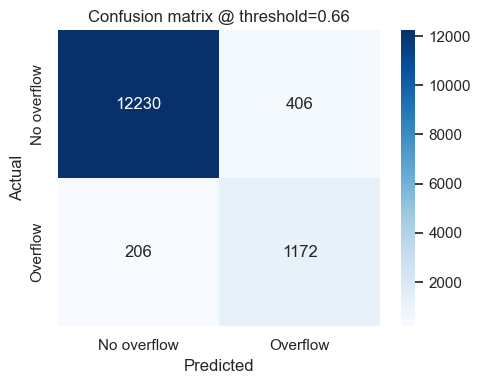

              precision    recall  f1-score   support

 No overflow       0.98      0.97      0.98     12636
    Overflow       0.74      0.85      0.79      1378

    accuracy                           0.96     14014
   macro avg       0.86      0.91      0.88     14014
weighted avg       0.96      0.96      0.96     14014



In [7]:
target_recall = 0.85
valid_idx = np.where(recalls[:-1] >= target_recall)[0]
chosen_idx = valid_idx[np.argmax(precisions[:-1][valid_idx])] if len(valid_idx) else np.argmax(recalls[:-1])
chosen_threshold = thresholds[chosen_idx]
print(f"Chosen threshold: {chosen_threshold:.3f} -> "
      f"Precision: {precisions[chosen_idx]:.3f}, Recall: {recalls[chosen_idx]:.3f}")

y_pred_at_threshold = (proba_test >= chosen_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_at_threshold)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No overflow", "Overflow"], yticklabels=["No overflow", "Overflow"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"Confusion matrix @ threshold={chosen_threshold:.2f}")
plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred_at_threshold, target_names=["No overflow", "Overflow"]))

## 6. Feature importance & SHAP

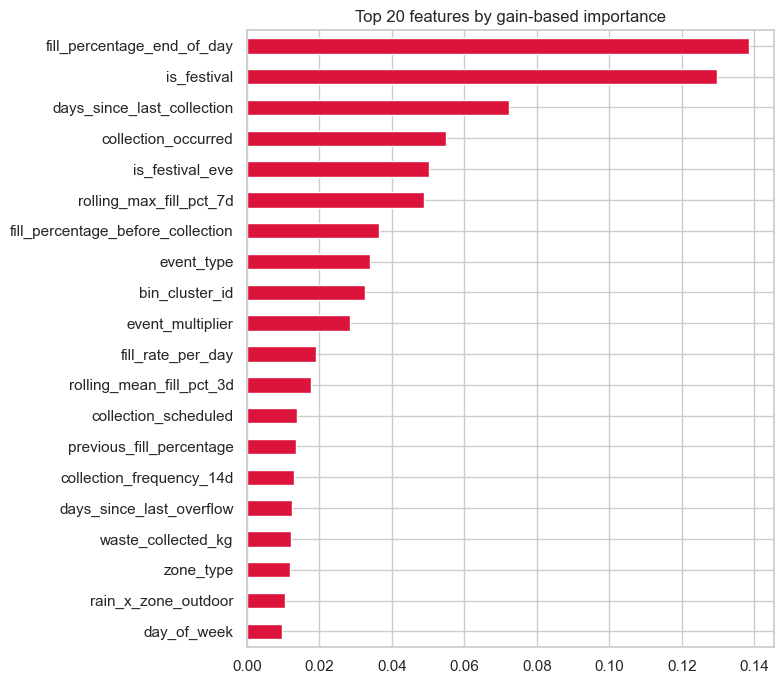

In [8]:
importance = pd.Series(clf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(20)
importance.plot(kind="barh", figsize=(8, 7), color="crimson")
plt.title("Top 20 features by gain-based importance")
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

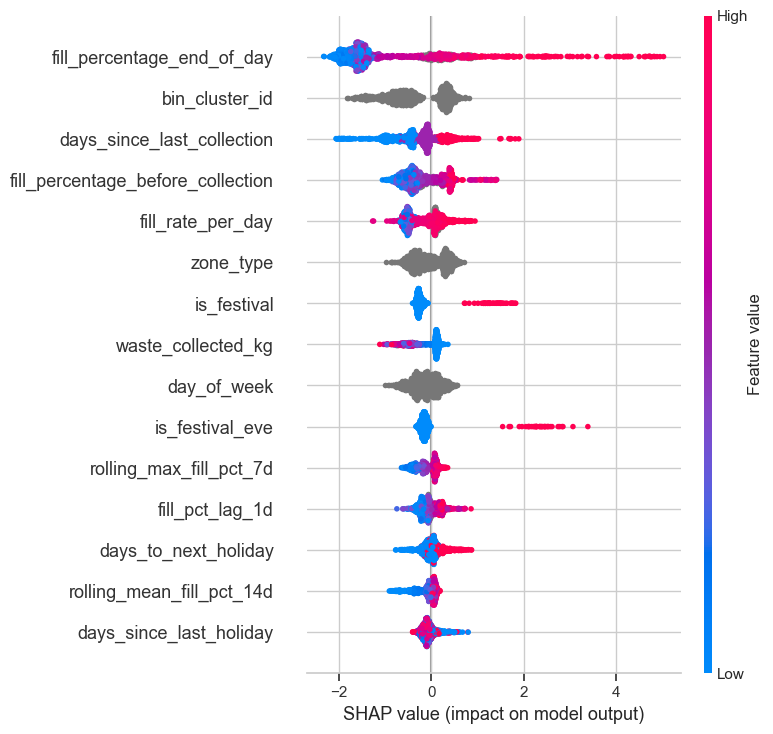

In [9]:
sample_idx = np.random.RandomState(42).choice(len(X_test), size=min(1500, len(X_test)), replace=False)
X_sample = X_test.iloc[sample_idx]

explainer = shap.TreeExplainer(clf)
shap_values = explainer(X_sample)

shap.summary_plot(shap_values, X_sample, show=False, max_display=15)
plt.tight_layout(); plt.show()

## 7. Save the model

In [10]:
clf.save_model("model2_overflow_risk_xgb.json")
print("Saved model2_overflow_risk_xgb.json")
print(f"Deployed decision threshold: {chosen_threshold:.3f} (store alongside the model for inference)")

Saved model2_overflow_risk_xgb.json
Deployed decision threshold: 0.660 (store alongside the model for inference)


## 8. Example output — the "Overflow risk: 87%" style report from the brief

In [11]:
# Same caveat as the regression notebook: the last calendar date has no
# valid "next day" target for any bin, so use the latest date that does.
latest_date = test.dropna(subset=[TARGET_CLASSIFICATION])["date"].max()
day_df = test[test["date"] == latest_date].dropna(subset=[TARGET_CLASSIFICATION])
sample_bins = day_df.sample(min(8, day_df.shape[0]), random_state=7)

X_show, y_show, meta_show = get_model_frame(sample_bins, TARGET_CLASSIFICATION, extra_categorical=["bin_cluster_id"])
proba_show = clf.predict_proba(X_show)[:, 1]

report = pd.DataFrame({
    "bin_id": meta_show["bin_id"].values,
    "zone_type": sample_bins["zone_type"].values,
    "current_fill_pct": sample_bins["fill_percentage_end_of_day"].round(1).values,
    "overflow_risk_pct": (proba_show * 100).round(1),
    "flagged_for_priority_collection": proba_show >= chosen_threshold,
    "actual_overflow_next_day": y_show.astype(bool).values,
}).sort_values("overflow_risk_pct", ascending=False)
report

,bin_id,zone_type,current_fill_pct,overflow_risk_pct,flagged_for_priority_collection,actual_overflow_next_day
2,BIN0046,market,40.0,8.2,False,False
7,BIN0067,mixed_use,NaN,4.8,False,False
3,BIN0012,market,37.7,4.2,False,False
4,BIN0053,mixed_use,37.1,3.2,False,False
1,BIN0127,tourist,26.1,2.7,False,False
0,BIN0089,residential_high,50.4,1.6,False,False
6,BIN0116,institutional,47.8,0.2,False,False
5,BIN0129,tourist,3.0,0.1,False,False


## 9. Summary
- XGBoost classifier with `scale_pos_weight` handles the 10.2% positive-class imbalance without synthetic oversampling.
- Threshold tuned for ~85% recall (catch most real overflow events), reporting the resulting precision as the honest trade-off.
- `overflow_risk_pct` from this notebook is what feeds OR-Tools' route-priority weights in the wider architecture — bins with higher scores get visited earlier.
- This closes the loop described in `ML_PIPELINE_PLAN.md`: Model 3 (clusters)  Models 1 & 2 (forecasts + risk)  route optimization (outside this notebook's scope).